# SmeltSense / RAPPG — Exploratory Data Analysis
## Industrial Data from the Electric Arc Furnace (DSP-120, ~125 t heats)

**Goal of this EDA.** We want to find feasible action sequences that **minimise electrical energy per tonne of steel**,
and (bonus) understand how what happens in the furnace affects the **downstream ladle furnace (LF)**.
So every section below answers one of three questions:

1. **What does a "normal" heat look like?** → dashboard KPI cards and "normal operating window" bands.
2. **What drives energy consumption?** → dashboard "energy drivers" panel, and the features for the model.
3. **What actions do operators actually take, and how often?** → the *historically supported* action space for RAPPG.

### 30-second glossary (data-science translation)

| Furnace term | What it means | Data-science analogy |
|---|---|---|
| **Heat** (`HEATID`) | One batch: load scrap → melt → refine → pour out. ~1 hour. | One *session* / one episode |
| **Basket charge** | Scrap metal dropped into the furnace from a big bucket (usually 2–3 per heat) | The episode's initial inputs |
| **Electrodes / arc** | Graphite rods; electricity arcs from them to the metal, like a giant welding torch | The main energy source (the cost we minimise) |
| **Transformer stage** (`TAP`) | The power setting, like the gears on a car. Higher stage → more power/longer arc | A discrete control action |
| **Power-on time** | Minutes the arc is actually running | Active time |
| **Oxygen lance** (`O2_*`) | Blows oxygen in. Burns carbon and some iron → releases heat ("chemical energy") | A continuous control that *substitutes* for electricity |
| **Gas burners** (`GAS_*`) | Natural-gas burners that help melt cold spots | Another energy input |
| **Carbon injection** (`INJ_*_CARBON`) | Blows carbon powder in. Makes the slag *foam*, which blankets the arc so less heat escapes | A continuous control that improves efficiency |
| **Slag** | The "scum" of oxides floating on the steel | By-product; also insulation |
| **Temperature / oxidation probe** (`TEMP`, `VALO2_PPM`) | A disposable probe dipped in by hand a few times per heat | Sparse, irregular observations of the hidden state |
| **Tapping** | Pouring the finished steel out into a ladle | End of episode |
| **Ladle furnace (LF)** | The next station downstream: fine-tunes chemistry & temperature | Downstream process |
| **Ferroalloys / deoxidisers** (`ferro.csv`) | Additives (Si, Mn, Al alloys…) to hit the recipe and remove oxygen | Downstream "cost of fixing" |

**Key operational idea:** energy is spent (1) melting scrap, (2) heating liquid steel up to tapping temperature,
and (3) *wasted* while the furnace sits hot waiting. Overheating costs energy; underheating costs energy downstream
(the LF must reheat). Over-oxidising saves some electricity (oxygen burns and releases heat) but loses iron to slag
and forces more deoxidiser additions downstream. **That is the trade-off RAPPG should expose.**

## 0. Setup
Point `DATA_DIR` at the folder containing the 11 CSV files from Kaggle.

In [ ]:
import kagglehub
path = kagglehub.dataset_download("yuriykatser/industrial-data-from-the-arc-furnace")

print(path)
import os
print(os.listdir(path))

100%|██████████| 100M/100M [00:00<00:00, 186MB/s] 

Extracting files...


/root/.cache/kagglehub/datasets/yuriykatser/industrial-data-from-the-arc-furnace/versions/3
['basket_charged.csv', 'eaf_final_chemical_measurements.csv', 'ladle_tapping.csv', 'eaf_transformer.csv', 'eaf_gaslance_mat.csv', 'eaf_added_materials.csv', 'lf_initial_chemical_measurements.csv', 'inj_mat.csv', 'ferro.csv', 'lf_added_materials.csv', 'eaf_temp.csv']


In [ ]:
from pathlib import Path
import json, re, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})

DATA_DIR = Path(path)
FIG_DIR  = Path("eda_outputs/figures"); FIG_DIR.mkdir(parents=True, exist_ok=True)
OUT_DIR  = Path("eda_outputs");         OUT_DIR.mkdir(parents=True, exist_ok=True)

FILES = {
    "temp":        "eaf_temp.csv",
    "eaf_chem":    "eaf_final_chemical_measurements.csv",
    "lf_chem":     "lf_initial_chemical_measurements.csv",
    "transformer": "eaf_transformer.csv",
    "basket":      "basket_charged.csv",
    "eaf_added":   "eaf_added_materials.csv",
    "inj":         "inj_mat.csv",
    "gas":         "eaf_gaslance_mat.csv",
    "ladle_tap":   "ladle_tapping.csv",
    "lf_added":    "lf_added_materials.csv",
    "ferro":       "ferro.csv",
}
TIME_COLS = ["DATETIME", "STARTTIME", "REVTIME", "FILTER_KEY_DATE"]

def savefig(name):
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"{name}.png", bbox_inches="tight")
    plt.show()

In [ ]:
print("running to_num function...")
def to_num(s):
    '''Coerce to float; handles decimal commas (the plant is Russian-speaking).'''
    if pd.api.types.is_numeric_dtype(s):
        return s.astype(float)
    return pd.to_numeric(s.astype(str).str.replace(",", ".", regex=False).str.strip(), errors="coerce")

print("running load function...")
def load(key):
    p = DATA_DIR / FILES[key]
    if not p.exists():
        print(f"  !! missing: {p}")
        return None
    df = pd.read_csv(p, low_memory=False)
    df.columns = [c.strip().upper() for c in df.columns]
    for c in df.columns:
        if c in TIME_COLS:
            df[c] = pd.to_datetime(df[c], errors="coerce")
        elif c.startswith("VAL") or c in ("TEMP", "MW", "CHARGE_AMOUNT", "CHARGED_AMOUNT", "MAT_CHARGED",
                                         "O2_AMOUNT", "GAS_AMOUNT",
                                         "O2_FLOW", "GAS_FLOW", "INJ_AMOUNT_CARBON", "INJ_FLOW_CARBON"):
            df[c] = to_num(df[c])
    return df

print("running D function...")
D = {k: load(k) for k in FILES}

print("running final for loop")
for k, df in D.items():
    if df is not None:
        print(f"{k:12s} {df.shape}  cols={list(df.columns)}")

running to_num function...
running load function...
running D function...
running final for loop
temp         (85104, 4)  cols=['HEATID', 'DATETIME', 'TEMP', 'VALO2_PPM']
eaf_chem     (3709, 15)  cols=['HEATID', 'POSITIONROW', 'DATETIME', 'VALC', 'VALSI', 'VALMN', 'VALP', 'VALS', 'VALCU', 'VALCR', 'VALMO', 'VALNI', 'VALAS', 'VALSN', 'VALN']
lf_chem      (20827, 12)  cols=['HEATID', 'POSITIONROW', 'DATETIME', 'VALC', 'VALSI', 'VALMN', 'VALP', 'VALS', 'VALCU', 'VALCR', 'VALMO', 'VALNI']
transformer  (271712, 5)  cols=['TAP', 'HEATID', 'STARTTIME', 'DURATION', 'MW']
basket       (137685, 5)  cols=['MAT_CODE', 'MAT_DEC', 'HEATID', 'DATETIME', 'CHARGED_AMOUNT']
eaf_added    (79944, 5)  cols=['MAT_CODE', 'MAT_DEC', 'HEATID', 'DATETIME', 'CHARGE_AMOUNT']
inj          (4011646, 4)  cols=['REVTIME', 'INJ_AMOUNT_CARBON', 'INJ_FLOW_CARBON', 'HEATID']
gas          (5748194, 6)  cols=['REVTIME', 'O2_AMOUNT', 'GAS_AMOUNT', 'O2_FLOW', 'GAS_FLOW', 'HEATID']
ladle_tap    (115873, 5)  cols=['HEATID', 'M

## 1. Data inventory — what do we actually have?
**Dashboard use:** a small "data health" panel. **Why it matters:** if half the heats have no chemistry,
the model for chemistry can only be trained on the other half — you need to know this before promising outcomes.

In [ ]:
inv = []
heat_sets = {}
for k, df in D.items():
    if df is None or k == "ferro":
        continue
    tcol = next((c for c in TIME_COLS if c in df.columns), None)
    heat_sets[k] = set(df["HEATID"].dropna().unique())
    inv.append({
        "table": k, "rows": len(df), "heats": df["HEATID"].nunique(),
        "rows_per_heat (median)": df.groupby("HEATID").size().median(),
        "first": df[tcol].min() if tcol else None,
        "last":  df[tcol].max() if tcol else None,
        "unparsed_times_%": round(100 * df[tcol].isna().mean(), 2) if tcol else None,
        "worst_missing_col": df.isna().mean().idxmax(),
        "worst_missing_%": round(100 * df.isna().mean().max(), 1),
    })
inventory = pd.DataFrame(inv).set_index("table")
inventory

,rows,heats,rows_per_heat (median),first,last,unparsed_times_%,worst_missing_col,worst_missing_%
table,,,,,,,,
temp,85104,20827,4.0,2015-01-01 01:30:00,2018-07-29 09:16:00,0.00,HEATID,0.0
eaf_chem,3709,3709,1.0,2015-01-01 02:22:00,2018-07-29 09:18:00,0.00,VALN,34.8
lf_chem,20827,20827,1.0,2015-01-01 03:10:00,2018-07-30 10:32:00,0.00,HEATID,0.0
transformer,271712,20813,13.0,2015-01-01 00:56:00,2018-07-29 08:51:00,0.00,TAP,0.0
basket,137685,20806,7.0,2015-01-01 00:51:00,2018-07-29 08:49:00,0.00,MAT_CODE,0.0
eaf_added,79944,20506,4.0,2015-01-01 01:02:00,2018-07-29 09:07:00,0.00,MAT_CODE,0.0
inj,4011646,20827,192.0,2015-01-01 00:50:37,2018-07-29 09:20:27,0.00,REVTIME,0.0
gas,5748194,20827,270.0,2015-01-01 00:50:37,2018-07-29 09:20:27,0.00,GAS_AMOUNT,0.0
ladle_tap,115873,20827,5.0,2015-01-01 01:35:00,2018-07-29 10:13:00,0.27,DATETIME,0.3


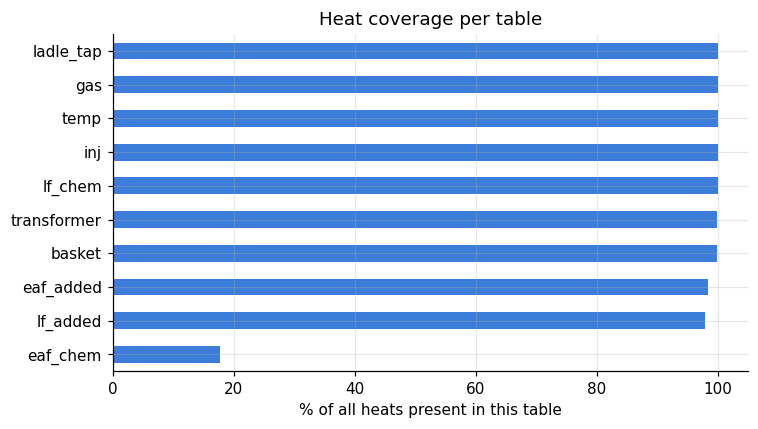

Total heats: 20,827 | heats with transformer+basket+temp (usable for energy work): 20,796
  ...and also with eaf_chem: 3,697
  ...and also with lf_chem: 20,796


In [ ]:
all_heats = set().union(*heat_sets.values())
cov = pd.Series({k: len(v) / len(all_heats) * 100 for k, v in heat_sets.items()}).sort_values()
ax = cov.plot.barh(figsize=(7, 4), color="#3b7dd8")
ax.set_xlabel("% of all heats present in this table"); ax.set_title("Heat coverage per table")
savefig("01_heat_coverage")

core = ["transformer", "basket", "temp"]
core_heats = set.intersection(*[heat_sets[k] for k in core if k in heat_sets])
print(f"Total heats: {len(all_heats):,} | heats with transformer+basket+temp (usable for energy work): {len(core_heats):,}")
for extra in ["eaf_chem", "lf_chem"]:
    if extra in heat_sets:
        print(f"  ...and also with {extra}: {len(core_heats & heat_sets[extra]):,}")

## 2. Build the heat table — one row per heat
This is the most important artefact of the EDA. It is the table the dashboard's history view, the energy model,
and the performance report all sit on. Each column is a plain-language KPI.

Notes on the logic (worth being able to explain):
- **Energy (MWh)** = Σ over transformer segments of `MW × duration`. If `MW` is average power during a segment, this is correct.
- **O₂ / gas / carbon** columns are *cumulative counters* that "start at zero and add up" and may not reset immediately
  at a new heat. So we sum only the **positive increments** within each heat, which ignores a stale carry-over value.
- **Tap temperature** = last temperature measurement before tapping (proxy — the probe is the only reading we have).

In [ ]:
def parse_duration_seconds(s):
    s2 = s.astype(str).str.replace(r"\s+", "", regex=True)
    def conv(x):
        if x in ("", "nan", "NaT", "None"):
            return np.nan
        try:
            parts = [int(p) for p in x.split(":")]
        except ValueError:
            return np.nan
        secs = 0
        for p in parts:
            secs = secs * 60 + p
        return float(secs)
    return s2.apply(conv)

tr = D["transformer"].copy()
tr["DUR_S"] = parse_duration_seconds(tr["DURATION"])
tr["ENDTIME"] = tr["STARTTIME"] + pd.to_timedelta(tr["DUR_S"], unit="s")
print((tr["MW"] < 0).sum(), "rows with negative MW (will be clipped to 0)")
tr["MW"] = tr["MW"].clip(lower=0)

bad_mw  = tr["MW"] > 150            # only an upper bound now — negatives handled above
bad_dur = tr["DUR_S"] <= 0
print(f"Dropping {(bad_mw | bad_dur).sum()} bad transformer rows "
      f"out of {len(tr)} ({100*(bad_mw|bad_dur).mean():.3f}%)")
tr = tr[~(bad_mw | bad_dur)].copy()
tr["ENDTIME"] = tr["STARTTIME"] + pd.to_timedelta(tr["DUR_S"], unit="s")
tr["MWH"] = tr["MW"] * tr["DUR_S"] / 3600
print("DURATION sample:", D["transformer"]["DURATION"].head(3).tolist(), "-> seconds:", tr["DUR_S"].head(3).tolist())
print(tr[["DUR_S", "MW", "MWH"]].describe().round(2))

22 rows with negative MW (will be clipped to 0)
Dropping 50 bad transformer rows out of 271712 (0.018%)
DURATION sample: [' 00: 29', ' 10: 40', ' 03: 00'] -> seconds: [29.0, 640.0, 180.0]
           DUR_S         MW        MWH
count  271662.00  271662.00  271662.00
mean      158.80       3.71       0.65
std       271.58       6.47       1.63
min         1.00       0.00       0.00
25%        10.00       0.25       0.00
50%        19.00       0.38       0.00
75%       150.00       3.50       0.14
max      2870.00      54.00      32.81


In [ ]:
print((tr["MW"] < 0).sum(), "negative rows")
print((tr["MW"].abs() > 150).sum(), "rows above plausible max")
tr["MW"].describe(percentiles=[.01, .05, .5, .95, .99])

0 negative rows
0 rows above plausible max


,MW
count,271662.000000
mean,3.711753
std,6.467167
min,0.000000
1%,0.000000
5%,0.000000
50%,0.375000
95%,18.750000
99%,27.250000
max,54.000000


In [ ]:
g = tr.groupby("HEATID")
energy = pd.DataFrame({
    "energy_mwh":        g["MWH"].sum(),
    "power_on_min":      g["DUR_S"].sum() / 60,
    "n_power_segments":  g.size(),
    "n_tap_changes":     g["TAP"].apply(lambda x: int((x.diff().fillna(0) != 0).sum())),
    "max_tap":           g["TAP"].max(),
    "arc_start":         g["STARTTIME"].min(),
    "arc_end":           g["ENDTIME"].max(),
})
energy["mean_mw"] = energy["energy_mwh"] / (energy["power_on_min"] / 60)

def mat_totals(df, prefix, amount_col="CHARGE_AMOUNT"):
    if df is None:
        return pd.DataFrame()
    gg = df.groupby("HEATID")
    return pd.DataFrame({f"{prefix}_amount": gg[amount_col].sum(),
                          f"{prefix}_n":      gg.size()})

basket = mat_totals(D["basket"], "basket", amount_col="CHARGED_AMOUNT")
added  = mat_totals(D["eaf_added"], "eaf_added")
ladle  = mat_totals(D["ladle_tap"], "ladle_tap")
lfadd  = mat_totals(D["lf_added"], "lf_added", amount_col="MAT_CHARGED")

# Unit check for charge amounts: a 125 t heat should total ~125 (t) or ~125,000 (kg)
med = basket["basket_amount"].median()
KG = med > 1000
print(f"Median basket total per heat = {med:,.0f} -> assuming units are {'kg' if KG else 'tonnes'}")
basket["charge_t"] = basket["basket_amount"] / (1000 if KG else 1)

def counter_total(df, col, tcol="REVTIME", sentinel=65000):
    d = df[df[col] < sentinel].dropna(subset=[col]).sort_values(["HEATID", tcol])
    inc = d.groupby("HEATID")[col].diff().clip(lower=0)
    return inc.groupby(d["HEATID"]).sum()

gas_tbl, inj_tbl = D["gas"], D["inj"]
cons = pd.DataFrame({
    "o2_total":     counter_total(gas_tbl, "O2_AMOUNT"),
    "gas_total":    counter_total(gas_tbl, "GAS_AMOUNT"),
    "carbon_total": counter_total(inj_tbl, "INJ_AMOUNT_CARBON"),
    "o2_flow_mean": gas_tbl[gas_tbl["O2_FLOW"] > 0].groupby("HEATID")["O2_FLOW"].mean(),
    "carbon_flow_mean": inj_tbl[inj_tbl["INJ_FLOW_CARBON"] > 0].groupby("HEATID")["INJ_FLOW_CARBON"].mean(),
})

tp = D["temp"].dropna(subset=["TEMP"]).sort_values(["HEATID", "DATETIME"])
tp["VALO2_PPM"] = tp["VALO2_PPM"].where(tp["VALO2_PPM"] > 0)   # 0 means "not measured"
gt = tp.groupby("HEATID")
temps = pd.DataFrame({
    "temp_first":  gt["TEMP"].first(),
    "temp_tap":    gt["TEMP"].last(),
    "n_temp_meas": gt.size(),
    "o2ppm_tap":   gt["VALO2_PPM"].last(),
    "time_first_temp": gt["DATETIME"].first(),
    "time_last_temp":  gt["DATETIME"].last(),
})

def chem_snapshot(df, prefix, which):
    if df is None:
        return pd.DataFrame()
    d = df.sort_values(["HEATID"] + [c for c in ["DATETIME", "POSITIONROW"] if c in df.columns])
    vals = [c for c in d.columns if c.startswith("VAL")]
    snap = getattr(d.groupby("HEATID")[vals], which)()
    snap.columns = [f"{prefix}_{c[3:].lower()}" for c in vals]
    return snap

eaf_chem = chem_snapshot(D["eaf_chem"], "eaf", "last")    # final EAF chemistry
lf_chem  = chem_snapshot(D["lf_chem"],  "lf",  "first")   # first LF chemistry = what arrived downstream

H = (energy.join([basket, added, cons, temps, eaf_chem, lf_chem, ladle, lfadd], how="left"))

# Heat duration
# Heat duration should reflect the EAF operation itself, not downstream ladle events.
# lf_chem/ladle_tap/lf_added timestamps are unreliable for this (~20hr median gap past
# arc_end -- looks like a data logging issue, not real elapsed time), so they're excluded here.
RELIABLE_DURATION_TABLES = ["transformer", "basket", "eaf_added", "temp"]

ev = []
for k in RELIABLE_DURATION_TABLES:
    df = D[k]
    if df is None: continue
    tcol = next((c for c in TIME_COLS if c in df.columns), None)
    if tcol: ev.append(df[["HEATID", tcol]].rename(columns={tcol: "t"}))
ev = pd.concat(ev).dropna().groupby("HEATID")["t"].agg(["min", "max"])

H["heat_start"] = ev["min"].reindex(H.index)
H["heat_duration_min"] = (ev["max"].reindex(H.index) - H["heat_start"]).dt.total_seconds() / 60

# Normalised KPIs — the ones operators and managers actually compare
H["kwh_per_t"]          = H["energy_mwh"] * 1000 / H["charge_t"]
H["o2_per_t"]           = H["o2_total"] / H["charge_t"]
H["carbon_per_t"]       = H["carbon_total"] / H["charge_t"]
H["gas_per_t"]          = H["gas_total"] / H["charge_t"]
H["power_off_min"]      = H["heat_duration_min"] - H["power_on_min"]
H["temp_rise"]          = H["temp_tap"] - H["temp_first"]
H = H.sort_values("heat_start")
print(H.shape)
H.head()

Median basket total per heat = 136,021 -> assuming units are kg
(20813, 57)


,energy_mwh,power_on_min,n_power_segments,n_tap_changes,max_tap,arc_start,arc_end,mean_mw,basket_amount,basket_n,charge_t,eaf_added_amount,eaf_added_n,o2_total,gas_total,carbon_total,o2_flow_mean,carbon_flow_mean,temp_first,temp_tap,n_temp_meas,o2ppm_tap,time_first_temp,time_last_temp,eaf_c,eaf_si,eaf_mn,eaf_p,eaf_s,eaf_cu,eaf_cr,eaf_mo,eaf_ni,eaf_as,eaf_sn,eaf_n,lf_c,lf_si,lf_mn,lf_p,lf_s,lf_cu,lf_cr,lf_mo,lf_ni,ladle_tap_amount,ladle_tap_n,lf_added_amount,lf_added_n,heat_start,heat_duration_min,kwh_per_t,o2_per_t,carbon_per_t,gas_per_t,power_off_min,temp_rise
HEATID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
5F0002,4.781944,16.833333,8.0,4.0,15.0,2015-01-01 00:56:00,2015-01-01 01:15:00,17.044554,128590.0,6.0,128.590,2763.0,4.0,7455.0,2301.0,1021.0,4087.392996,71.740260,1598.0,1650.0,3,403.0,2015-01-01 01:30:00,2015-01-01 01:32:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.1457,0.2760,0.5306,0.1457,0.0167,0.1998,0.5240,0.2760,0.1201,3780.0,8,1105.000,9.0,2015-01-01 00:51:00,41.0,37.187530,57.974959,7.939964,17.894082,24.166667,52.0
5F0003,12.317708,33.500000,8.0,5.0,15.0,2015-01-01 01:41:00,2015-01-01 02:17:00,22.061567,128826.0,6.0,128.826,2758.0,4.0,7128.0,2277.0,957.0,3864.946281,74.013514,1629.0,1653.0,2,698.0,2015-01-01 02:17:00,2015-01-01 02:18:00,0.0823,0.0172,0.0615,0.0823,0.0361,0.1913,0.0916,0.0172,0.1075,0.0053,0.0068,0.0361,0.1359,0.2898,0.5285,0.1359,0.0048,0.1897,0.5159,0.2898,0.1076,2766.0,7,339.000,2.0,2015-01-01 01:39:00,39.0,95.615080,55.330446,7.428625,17.675003,5.500000,24.0
5F0004,7.157986,34.333333,13.0,6.0,15.0,2015-01-01 02:26:00,2015-01-01 03:18:30,12.509102,133715.0,4.0,133.715,4055.0,4.0,7074.0,2321.0,789.0,3195.951952,70.060606,1636.0,1636.0,2,700.0,2015-01-01 03:17:00,2015-01-01 03:18:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.2183,0.3296,1.1203,0.2183,0.0273,0.2372,0.0942,0.3296,0.1003,2238.0,5,1726.161,12.0,2015-01-01 02:24:00,54.0,53.531661,52.903564,5.900610,17.357813,19.666667,0.0
5F0005,10.843160,35.683333,11.0,5.0,15.0,2015-01-01 03:27:00,2015-01-01 04:07:20,18.232310,129233.0,6.0,129.233,2753.0,4.0,7283.0,2395.0,812.0,4102.526923,59.230769,1621.0,1641.0,3,669.0,2015-01-01 04:05:00,2015-01-01 04:07:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.1436,0.2701,0.5227,0.1436,0.0092,0.1948,0.4835,0.2701,0.1021,3765.0,8,2673.032,24.0,2015-01-01 03:25:00,42.0,83.903954,56.355575,6.283225,18.532418,6.316667,20.0
5F0006,11.211806,35.000000,11.0,4.0,15.0,2015-01-01 04:16:00,2015-01-01 04:55:40,19.220238,132505.0,4.0,132.505,4054.0,4.0,3655.0,1171.0,882.0,3969.488636,59.975610,1620.0,1651.0,5,789.0,2015-01-01 04:53:00,2015-01-01 04:57:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.2368,0.2227,1.3179,0.2368,0.0165,0.2437,0.0839,0.2227,0.1216,3170.0,5,1065.000,8.0,2015-01-01 04:15:00,42.0,84.614207,27.583865,6.656353,8.837402,7.000000,31.0


### 2b. Data quality flags
Physically impossible or suspicious values. **Dashboard use:** grey these heats out rather than silently dropping them.
Rough plausibility ranges for a scrap EAF (ask a metallurgist to confirm):
liquid steel tap temperature ≈ 1550–1700 °C, heat size ≈ 100–150 t, specific electrical energy typically a few hundred kWh/t.
If your median kWh/t is ~10× off, the `MW`/`DURATION` units are being interpreted wrongly.

In [ ]:
q = pd.DataFrame(index=H.index)
q["no_energy"]        = ~(H["energy_mwh"] > 0)
q["no_charge"]        = ~(H["charge_t"] > 0)
q["weird_charge"]     = (H["charge_t"] < 60) | (H["charge_t"] > 200)
q["weird_tap_temp"]   = (H["temp_tap"] < 1450) | (H["temp_tap"] > 1800)
q["kwh_t_outlier"]    = (H["kwh_per_t"] < H["kwh_per_t"].quantile(0.005)) | (H["kwh_per_t"] > H["kwh_per_t"].quantile(0.995))
q["too_long"]         = H["heat_duration_min"] > 240   # anything over 4 hours is almost certainly a data issue, not a real heat
q["too_short"]        = H["heat_duration_min"] < 10   # a real EAF heat won't melt 125t scrap in under 10 min
print((q.mean() * 100).round(2).rename("% of heats flagged"))
H["quality_ok"] = ~q.any(axis=1)
print(f"\nClean heats: {H['quality_ok'].sum():,} / {len(H):,}")
print(f"Median kWh/t (clean): {H.loc[H.quality_ok, 'kwh_per_t'].median():.0f}")
Hc = H[H["quality_ok"]].copy()

no_energy         0.00
no_charge         0.08
weird_charge      0.18
weird_tap_temp    0.00
kwh_t_outlier     1.00
too_long          6.06
too_short         0.00
Name: % of heats flagged, dtype: float64

Clean heats: 19,368 / 20,813
Median kWh/t (clean): 60


In [ ]:
# Look at the actual power profile for one heat, unaggregated
sample = tr[tr["HEATID"] == "5F0002"][["STARTTIME", "TAP", "MW", "DUR_S", "MWH"]].sort_values("STARTTIME")
print(sample)
print("\nTotal MWh this heat:", sample["MWH"].sum())
print("Total scrap this heat (t):", H.loc["5F0002", "charge_t"])
print("Implied kWh/t:", sample["MWH"].sum() * 1000 / H.loc["5F0002", "charge_t"])

# Distribution of MW specifically during the highest transformer stages (should be near-full power)
print("\nMW stats at max tap stage (17):")
print(tr[tr["TAP"] == tr["TAP"].max()]["MW"].describe())

                 STARTTIME  TAP      MW  DUR_S       MWH
180214 2015-01-01 00:56:00   15  16.500  720.0  3.300000
180216 2015-01-01 00:56:00   11   1.000   10.0  0.002778
180218 2015-01-01 00:56:00   12   0.375   10.0  0.001042
180219 2015-01-01 00:56:00   13   0.125   10.0  0.000347
180217 2015-01-01 01:11:00   11   1.250   60.0  0.020833
180213 2015-01-01 01:12:00   14   0.125   10.0  0.000347
180215 2015-01-01 01:12:00   15  29.125  180.0  1.456250
180220 2015-01-01 01:12:00   13   0.125   10.0  0.000347

Total MWh this heat: 4.781944444444445
Total scrap this heat (t): 128.59
Implied kWh/t: 37.187529702499766

MW stats at max tap stage (17):
count    325.000000
mean       6.449231
std        4.012161
min        0.000000
25%        3.000000
50%        6.250000
75%        9.000000
max       27.625000
Name: MW, dtype: float64


## 3. What does a normal heat look like? (KPI distributions)
**Dashboard use:** each histogram becomes a KPI card with a green band = P10–P90 ("normal operating window").
When a live heat drifts outside the band, the card turns amber. This is simple, explainable, and operators trust it.

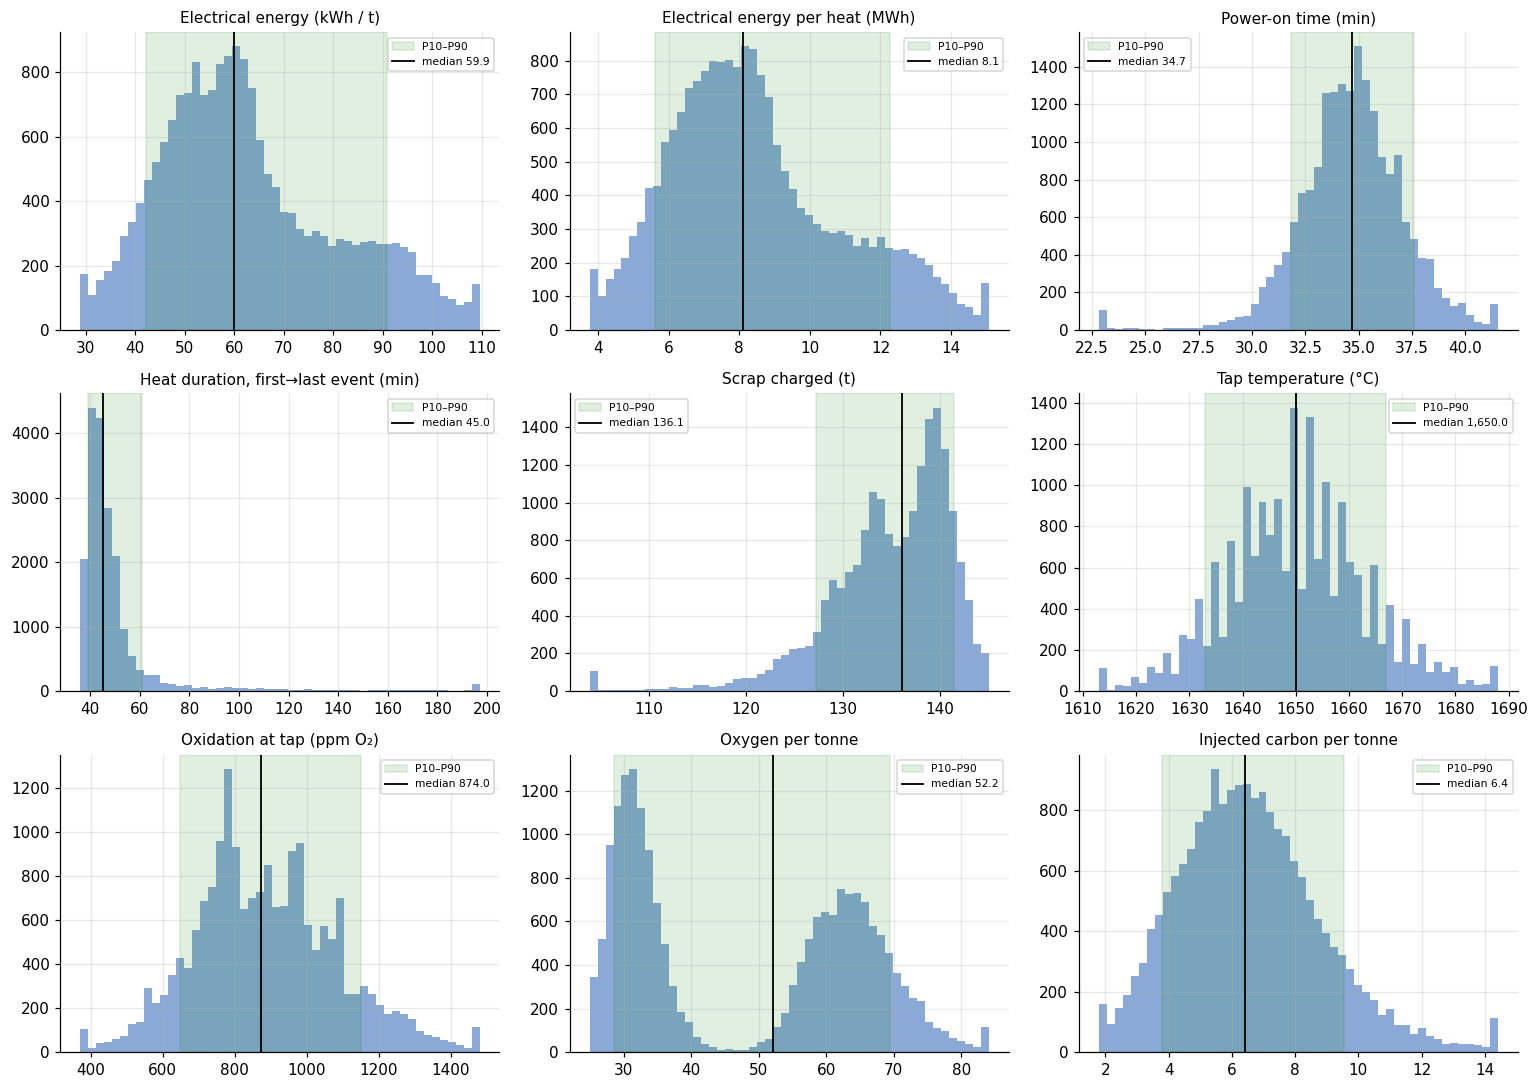

,label,p10,p50,p90,n
kwh_per_t,Electrical energy (kWh / t),42.121937,59.89726,90.818404,19368
energy_mwh,Electrical energy per heat (MWh),5.619358,8.10941,12.271979,19368
power_on_min,Power-on time (min),31.833333,34.683333,37.583333,19368
heat_duration_min,"Heat duration, first→last event (min)",39.0,45.0,61.0,19368
charge_t,Scrap charged (t),127.1847,136.0935,141.42,19368
temp_tap,Tap temperature (°C),1633.0,1650.0,1667.0,19368
o2ppm_tap,Oxidation at tap (ppm O₂),649.0,874.0,1150.0,19219
o2_per_t,Oxygen per tonne,28.648413,52.158108,69.439542,19368
carbon_per_t,Injected carbon per tonne,3.781456,6.400212,9.540259,19368


In [ ]:
KPIS = {
    "kwh_per_t":         "Electrical energy (kWh / t)",
    "energy_mwh":        "Electrical energy per heat (MWh)",
    "power_on_min":      "Power-on time (min)",
    "heat_duration_min": "Heat duration, first→last event (min)",
    "charge_t":          "Scrap charged (t)",
    "temp_tap":          "Tap temperature (°C)",
    "o2ppm_tap":         "Oxidation at tap (ppm O₂)",
    "o2_per_t":          "Oxygen per tonne",
    "carbon_per_t":      "Injected carbon per tonne",
}
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
window = {}
for ax, (col, label) in zip(axes.ravel(), KPIS.items()):
    s = Hc[col].dropna()
    if s.empty: ax.set_title(f"{label}\n(no data)"); continue
    p10, p50, p90 = s.quantile([.1, .5, .9])
    window[col] = {"label": label, "p10": p10, "p50": p50, "p90": p90, "n": int(s.size)}
    ax.hist(s.clip(s.quantile(.005), s.quantile(.995)), bins=50, color="#8aa9d6")
    ax.axvspan(p10, p90, color="green", alpha=0.12, label="P10–P90")
    ax.axvline(p50, color="k", lw=1.2, label=f"median {p50:,.1f}")
    ax.set_title(label, fontsize=10); ax.legend(fontsize=7)
savefig("03_kpi_distributions")
normal_window = pd.DataFrame(window).T
normal_window

## 4. What drives energy per tonne?
This is the core of the problem statement. We look at simple (rank) correlations first because they are robust to
outliers and easy to explain: *"heats with more X tend to use more/less energy per tonne."*

**Correlation ≠ lever.** E.g. long power-off time correlates with high energy because a hot, idle furnace loses heat —
but the *cause* might be a crane delay, not an operator choice. Keep a "can the operator control this?" column in mind.

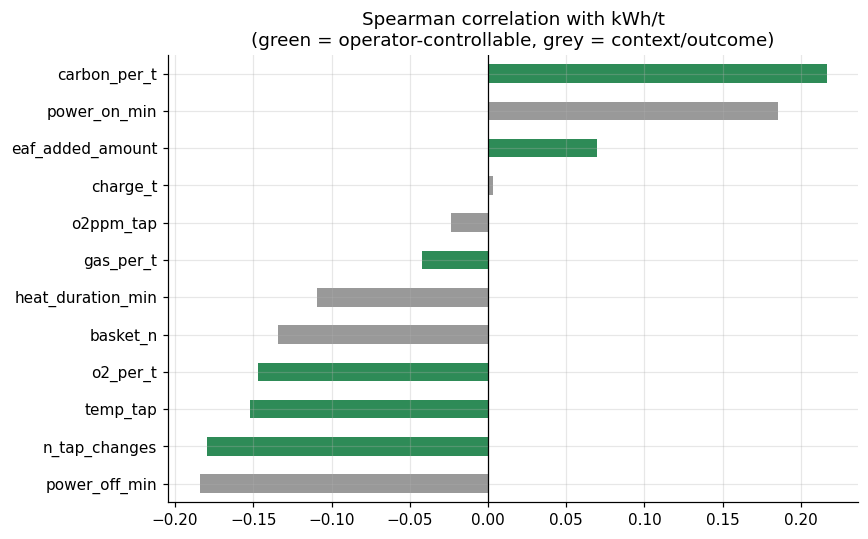

In [ ]:
drivers = ["power_on_min", "power_off_min", "heat_duration_min", "charge_t", "o2_per_t", "gas_per_t",
           "carbon_per_t", "n_tap_changes", "basket_n", "eaf_added_amount", "temp_tap", "o2ppm_tap"]
drivers = [d for d in drivers if d in Hc and Hc[d].notna().sum() > 30]
corr = Hc[drivers + ["kwh_per_t"]].corr(method="spearman")["kwh_per_t"].drop("kwh_per_t").sort_values()
CONTROLLABLE = {"o2_per_t", "gas_per_t", "carbon_per_t", "n_tap_changes", "temp_tap", "eaf_added_amount"}
colors = ["#2e8b57" if d in CONTROLLABLE else "#999999" for d in corr.index]
ax = corr.plot.barh(figsize=(8, 5), color=colors)
ax.set_title("Spearman correlation with kWh/t\n(green = operator-controllable, grey = context/outcome)")
ax.axvline(0, color="k", lw=0.8)
savefig("04_energy_driver_correlations")

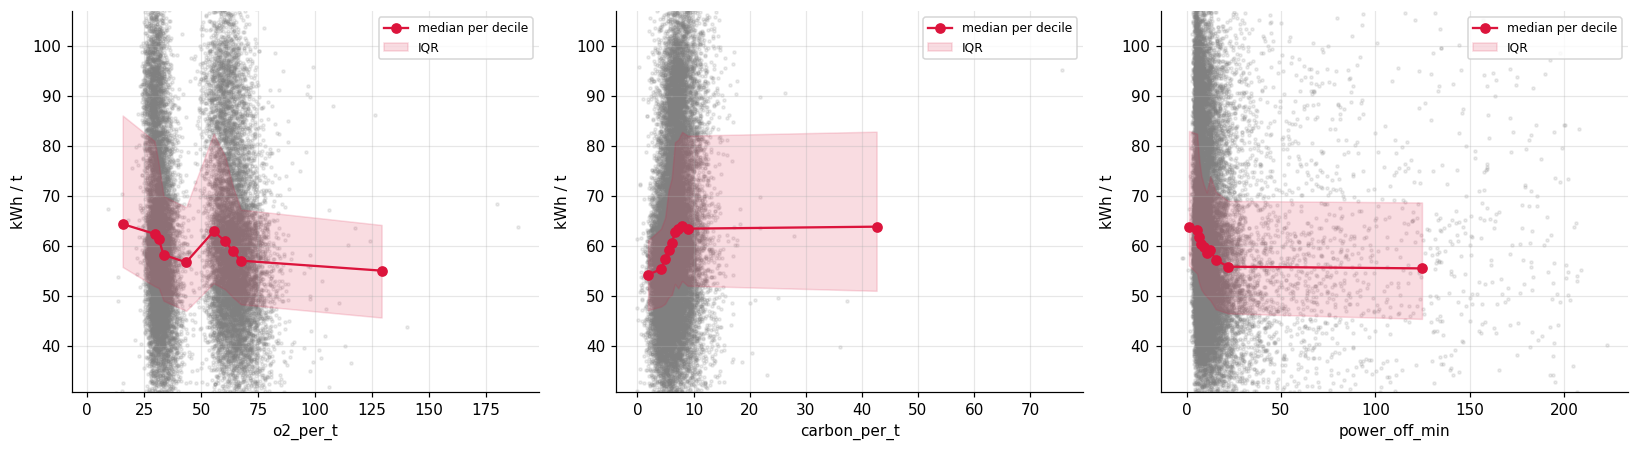

In [ ]:
# The chemical-vs-electrical energy trade-off: does more oxygen/carbon per tonne buy lower kWh/t?
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
for ax, col in zip(axes, ["o2_per_t", "carbon_per_t", "power_off_min"]):
    d = Hc[[col, "kwh_per_t"]].dropna()
    if len(d) < 20: continue
    d["bin"] = pd.qcut(d[col], 10, duplicates="drop")
    b = d.groupby("bin", observed=True)["kwh_per_t"].agg(["median", lambda x: x.quantile(.25), lambda x: x.quantile(.75)])
    x = [i.mid for i in b.index]
    ax.scatter(d[col], d["kwh_per_t"], s=4, alpha=0.15, color="grey")
    ax.plot(x, b["median"], "o-", color="crimson", label="median per decile")
    ax.fill_between(x, b.iloc[:, 1], b.iloc[:, 2], color="crimson", alpha=0.15, label="IQR")
    ax.set_ylim(Hc["kwh_per_t"].quantile(.01), Hc["kwh_per_t"].quantile(.99))
    ax.set_xlabel(col); ax.set_ylabel("kWh / t"); ax.legend(fontsize=8)
savefig("04b_tradeoff_curves")

### 4b. "What do our best heats do differently?"
Split heats into the most efficient 20% and least efficient 20% (by kWh/t) and compare medians.
**Dashboard use:** a benchmark table. **Explaining it:** this is the plant's own best practice, discovered from data —
it is also a sanity baseline your RAPPG recommendations should agree with.

In [ ]:
lo, hi = Hc["kwh_per_t"].quantile([.2, .8])
best, worst = Hc[Hc["kwh_per_t"] <= lo], Hc[Hc["kwh_per_t"] >= hi]
cmp_cols = [c for c in drivers + ["kwh_per_t", "temp_rise"] if c in Hc]
bench = pd.DataFrame({"best 20%": best[cmp_cols].median(), "worst 20%": worst[cmp_cols].median()})
bench["difference %"] = (100 * (bench["worst 20%"] - bench["best 20%"]) / bench["best 20%"].abs()).round(1)
bench.round(2).sort_values("difference %", key=abs, ascending=False)

,best 20%,worst 20%,difference %
kwh_per_t,42.12,90.82,115.6
o2_per_t,56.46,35.95,-36.3
power_off_min,12.17,8.47,-30.4
carbon_per_t,5.96,7.27,21.9
n_tap_changes,7.00,6.00,-14.3
basket_n,7.00,6.00,-14.3
gas_per_t,8.77,7.82,-10.9
temp_rise,29.00,26.00,-10.3
eaf_added_amount,2389.00,2543.00,6.4
heat_duration_min,46.00,44.00,-4.3


## 5. The action space — what do operators actually do?
RAPPG can only responsibly recommend actions that have **historical support** (enough past examples to learn their
effect). This section defines the candidate discrete actions and counts how often each occurs.

- **Transformer stage (TAP):** already discrete — the "gear" of the furnace.
- **O₂ flow and carbon flow:** continuous, so we bin them into *low / medium / high* by tertiles (as the proof-of-concept doc suggests).

In [ ]:
# fig, axes = plt.subplots(1, 3, figsize=(15, 4))
# tap_time = tr.groupby("TAP")["DUR_S"].sum() / 3600
# tap_time.plot.bar(ax=axes[0], color="#3b7dd8"); axes[0].set_title("Hours of arc time per transformer stage"); axes[0].set_ylabel("hours")
# tr.groupby("TAP")["MW"].median().plot(ax=axes[1], marker="o"); axes[1].set_title("Median MW by transformer stage"); axes[1].set_ylabel("MW")
# # How is the energy spread across stages within a typical heat?
# share = tr.pivot_table(index="HEATID", columns="TAP", values="MWH", aggfunc="sum").fillna(0)
# share = share.div(share.sum(axis=1), axis=0)
# share.median().plot.bar(ax=axes[2], color="#e08a3c"); axes[2].set_title("Median share of heat's energy per stage")
# savefig("05_transformer_stage_usage")

In [ ]:
def tertile_actions(series, name):
     s = series[series > 0].dropna()
     cuts = s.quantile([1/3, 2/3]).values
     labels = pd.cut(s, [-np.inf, *cuts, np.inf], labels=[f"{name}_low", f"{name}_med", f"{name}_high"])
     return cuts, labels.value_counts().sort_index()

o2_cuts, o2_counts = tertile_actions(gas_tbl["O2_FLOW"], "O2")
c_cuts,  c_counts  = tertile_actions(inj_tbl["INJ_FLOW_CARBON"], "C")
print("O2 flow bin edges:", np.round(o2_cuts, 1)); print(o2_counts, "\n")
print("Carbon flow bin edges:", np.round(c_cuts, 1)); print(c_counts)
action_bins = {"o2_flow_edges": o2_cuts.tolist(), "carbon_flow_edges": c_cuts.tolist(),
                "transformer_stages": sorted(tr["TAP"].dropna().unique().tolist())}

O2 flow bin edges: [1498. 4323.]
O2_FLOW
O2_low     1492766
O2_med     1486289
O2_high    1488952
Name: count, dtype: int64 

Carbon flow bin edges: [62. 84.]
INJ_FLOW_CARBON
C_low     479365
C_med     471594
C_high    470493
Name: count, dtype: int64


## 6. Heat replay — one heat, end to end
**Dashboard use:** this is the "live view" an operator would see, and the best single picture for *you* to explain
the process to judges: power goes on → scrap melts → oxygen & carbon are injected → temperature is probed → tap.

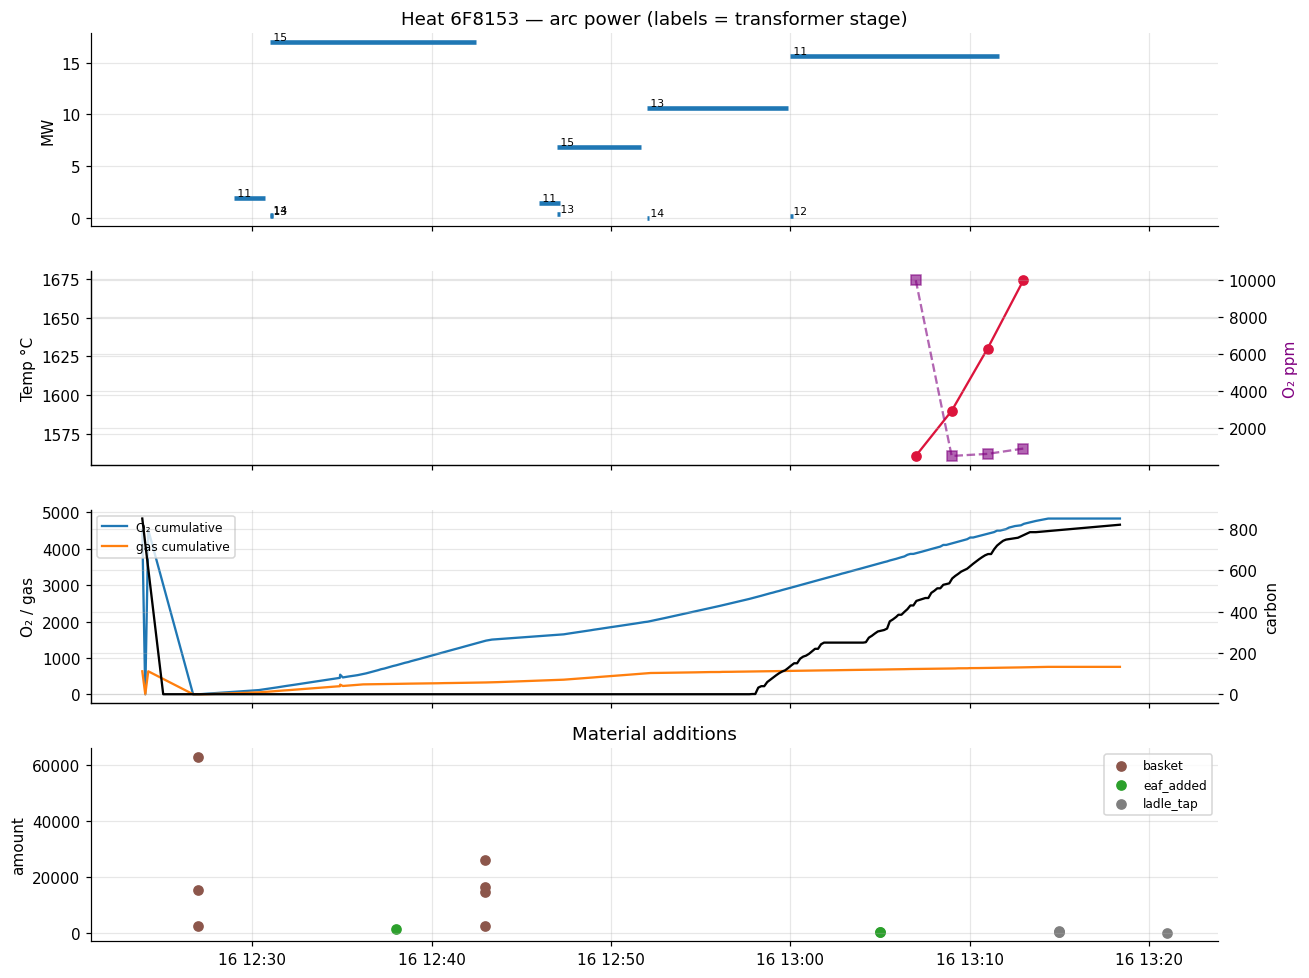

In [ ]:
def heat_replay(hid):
    fig, ax = plt.subplots(4, 1, figsize=(12, 9), sharex=True)
    t = tr[tr.HEATID == hid].sort_values("STARTTIME")
    for _, r in t.iterrows():
        ax[0].hlines(r.MW, r.STARTTIME, r.ENDTIME, lw=3)
        ax[0].text(r.STARTTIME, r.MW, f" {r.TAP:.0f}", fontsize=7, va="bottom")
    ax[0].set_ylabel("MW"); ax[0].set_title(f"Heat {hid} — arc power (labels = transformer stage)")
    tt = tp[tp.HEATID == hid]
    ax[1].plot(tt.DATETIME, tt.TEMP, "o-", color="crimson"); ax[1].set_ylabel("Temp °C")
    ax1b = ax[1].twinx(); ax1b.plot(tt.DATETIME, tt.VALO2_PPM, "s--", color="purple", alpha=.6); ax1b.set_ylabel("O₂ ppm", color="purple")
    gg = gas_tbl[gas_tbl.HEATID == hid].sort_values("REVTIME")
    ii = inj_tbl[inj_tbl.HEATID == hid].sort_values("REVTIME")
    ax[2].plot(gg.REVTIME, gg.O2_AMOUNT, label="O₂ cumulative"); ax[2].plot(gg.REVTIME, gg.GAS_AMOUNT, label="gas cumulative")
    ax2b = ax[2].twinx(); ax2b.plot(ii.REVTIME, ii.INJ_AMOUNT_CARBON, color="k", label="carbon cumulative"); ax2b.set_ylabel("carbon")
    ax[2].legend(loc="upper left", fontsize=8); ax[2].set_ylabel("O₂ / gas")
    AMOUNT_COL = {"basket": "CHARGED_AMOUNT", "eaf_added": "CHARGE_AMOUNT", "ladle_tap": "CHARGE_AMOUNT"}
    for key, col in [("basket", "tab:brown"), ("eaf_added", "tab:green"), ("ladle_tap", "tab:gray")]:
        m = D[key]
        if m is None: continue
        m = m[m.HEATID == hid]
        ax[3].scatter(m.DATETIME, m[AMOUNT_COL[key]], label=key, color=col)
    ax[3].set_ylabel("amount"); ax[3].legend(fontsize=8); ax[3].set_title("Material additions")
    savefig(f"06_heat_replay_{hid}")

# a typical heat: closest to median kWh/t among heats with plenty of temp readings
cand = Hc[Hc.n_temp_meas >= Hc.n_temp_meas.median()]
typical = (cand["kwh_per_t"] - cand["kwh_per_t"].median()).abs().idxmin()
heat_replay(typical)

## 7. Transition table — the raw material for RAPPG's P(Sₜ₊₁ | Sₜ, aₜ)
Between two consecutive temperature probes we know: the state before (temperature, O₂ ppm), what was done in between
(electrical energy, oxygen, carbon, additions), and the state after. Each row is one observed **state → action → next state** step.

**Why it matters:** this reframes the problem from "predict final energy from a summary row" to the *sequential decision problem*
RAPPG needs. Heating efficiency (°C gained per MWh) is also a great operator KPI — it drops when the slag isn't foaming or the arc is exposed.

In [ ]:
# def clean_cumulative(df, col):
#     d = df.dropna(subset=[col]).sort_values(["HEATID", "REVTIME"])[["HEATID", "REVTIME", col]].copy()
#     d["cum"] = d.groupby("HEATID")[col].diff().clip(lower=0).fillna(0)
#     d["cum"] = d.groupby("HEATID")["cum"].cumsum()
#     return {h: (x["REVTIME"].values, x["cum"].values) for h, x in d.groupby("HEATID")}

# def at_time(series, t):
#     times, vals = series
#     i = np.searchsorted(times, np.datetime64(t), side="right") - 1
#     return vals[i] if i >= 0 else 0.0

# o2_c, c_c = clean_cumulative(gas_tbl, "O2_AMOUNT"), clean_cumulative(inj_tbl, "INJ_AMOUNT_CARBON")
# tr_by = {h: x for h, x in tr.groupby("HEATID")}
# add_by = {h: x for h, x in D["eaf_added"].groupby("HEATID")} if D["eaf_added"] is not None else {}
# empty = (np.array([], dtype="datetime64[ns]"), np.array([]))

# rows = []
# for hid, th in tp[tp.HEATID.isin(Hc.index)].groupby("HEATID"):
#     if len(th) < 2 or hid not in tr_by: continue
#     seg = tr_by[hid]; s0 = seg.STARTTIME.values; s1 = seg.ENDTIME.values; mw = seg.MW.values
#     times, T, ppm = th.DATETIME.values, th.TEMP.values, th.VALO2_PPM.values
#     for k in range(len(th) - 1):
#         a, b = times[k], times[k + 1]
#         overlap_h = np.clip((np.minimum(s1, b) - np.maximum(s0, a)) / np.timedelta64(1, "h"), 0, None)
#         ad = add_by.get(hid)
#         rows.append({
#             "HEATID": hid, "step": k, "t0": a, "dt_min": (b - a) / np.timedelta64(1, "m"),
#             "temp_0": T[k], "o2ppm_0": ppm[k], "temp_1": T[k + 1], "o2ppm_1": ppm[k + 1],
#             "energy_mwh": float((overlap_h * mw).sum()),
#             "o2_used": at_time(o2_c.get(hid, empty), b) - at_time(o2_c.get(hid, empty), a),
#             "carbon_used": at_time(c_c.get(hid, empty), b) - at_time(c_c.get(hid, empty), a),
#             "additions": float(ad[(ad.DATETIME > a) & (ad.DATETIME <= b)].CHARGE_AMOUNT.sum()) if ad is not None else 0.0,
#         })
# T_tbl = pd.DataFrame(rows)
# T_tbl["dT"] = T_tbl["temp_1"] - T_tbl["temp_0"]
# T_tbl["degC_per_mwh"] = T_tbl["dT"] / T_tbl["energy_mwh"].where(T_tbl["energy_mwh"] > 0.5)
# print(f"{len(T_tbl):,} transitions from {T_tbl.HEATID.nunique():,} heats")
# T_tbl.describe().round(2)

In [ ]:
# fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
# d = T_tbl.dropna(subset=["degC_per_mwh"])
# d = d[d.degC_per_mwh.between(d.degC_per_mwh.quantile(.02), d.degC_per_mwh.quantile(.98))]
# axes[0].hist(d.degC_per_mwh, bins=60, color="#8aa9d6"); axes[0].set_title("Heating efficiency between probes (°C per MWh)")
# axes[1].scatter(d.energy_mwh, d.dT, s=5, alpha=.25); axes[1].set_xlabel("MWh delivered between probes"); axes[1].set_ylabel("temperature change °C")
# axes[1].set_title("Energy in → temperature out (each dot = one transition)")
# savefig("07_heating_efficiency")

## 8. Downstream — what the ladle furnace inherits (bonus objective)
The EAF's decisions are "paid for" downstream. Two signals we can see:

1. **Chemistry shift EAF → LF**: how much each element changes between the last EAF sample and the first LF sample.
2. **Oxidation at tap vs ladle additions**: higher O₂ ppm at tap usually means more deoxidisers must be added in the ladle —
   that's the downstream cost of an aggressive oxygen strategy in the EAF.
3. **Tap temperature vs LF**: tapping too cold means the LF has to reheat (energy moved, not saved).

In [ ]:
# elems = sorted({c.split("_", 1)[1] for c in Hc.columns if c.startswith("eaf_")} &
#                {c.split("_", 1)[1] for c in Hc.columns if c.startswith("lf_") and not c.startswith("lf_added")})
# if elems:
#     delta = pd.DataFrame({e: Hc[f"lf_{e}"] - Hc[f"eaf_{e}"] for e in elems})
#     rel = delta.div(Hc[[f"eaf_{e}" for e in elems]].abs().replace(0, np.nan).values)
#     fig, ax = plt.subplots(figsize=(11, 4))
#     ax.boxplot([rel[e].dropna().clip(-3, 3) for e in elems], labels=elems, showfliers=False)
#     ax.axhline(0, color="k", lw=.8); ax.set_ylabel("relative change (LF − EAF) / EAF")
#     ax.set_title("How chemistry changes between EAF final and LF initial sample (additions at tapping happen here)")
#     savefig("08_chem_shift_eaf_to_lf")
# else:
#     print("No matching chemistry columns found.")

In [ ]:
# fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
# d = Hc[["o2ppm_tap", "ladle_tap_amount"]].dropna()
# if len(d) > 20:
#     d["bin"] = pd.qcut(d.o2ppm_tap, 8, duplicates="drop")
#     b = d.groupby("bin", observed=True)["ladle_tap_amount"].median()
#     axes[0].scatter(d.o2ppm_tap, d.ladle_tap_amount, s=4, alpha=.2, color="grey")
#     axes[0].plot([i.mid for i in b.index], b.values, "o-", color="crimson")
#     axes[0].set_xlabel("O₂ ppm at tap"); axes[0].set_ylabel("ladle additions at tapping"); axes[0].set_title("More oxidised steel → more additions downstream?")
# d2 = Hc[["o2_per_t", "o2ppm_tap"]].dropna()
# axes[1].scatter(d2.o2_per_t, d2.o2ppm_tap, s=4, alpha=.25)
# axes[1].set_xlabel("O₂ blown per tonne"); axes[1].set_ylabel("O₂ ppm at tap"); axes[1].set_title("EAF oxygen strategy → oxidation at tap")
# savefig("08b_downstream_tradeoff")

In [ ]:
# # Which materials are added at tapping? (join to ferro.csv for descriptions/composition)
# if D["ladle_tap"] is not None:
#     top = (D["ladle_tap"].groupby("MAT_CODE")["CHARGE_AMOUNT"].agg(["sum", "count"])
#            .sort_values("sum", ascending=False).head(12))
#     if D["ferro"] is not None and "MAT_CODE" in D["ferro"]:
#         top = top.join(D["ferro"].drop_duplicates("MAT_CODE").set_index("MAT_CODE"), how="left")
#     display(top)

## 9. Trends over time — is the furnace drifting?
Refractory (the furnace's heat-resistant lining) wears over a campaign; electrodes and practices change. A rising
kWh/t trend is an early sign. **Dashboard use:** the "plant performance over time" panel. **Modelling use:** if there is
drift, the train/test split must be **chronological**, not random, or the model's accuracy report will be optimistic.

In [ ]:
# s = Hc.set_index("heat_start")["kwh_per_t"].dropna().sort_index()
# fig, axes = plt.subplots(2, 1, figsize=(13, 7))
# axes[0].plot(s.index, s.values, ".", ms=2, alpha=.3, color="grey")
# axes[0].plot(s.rolling(100, min_periods=30).median(), color="crimson", label="rolling median (100 heats)")
# axes[0].set_ylabel("kWh / t"); axes[0].legend(); axes[0].set_title("Energy intensity over time")
# Hc.set_index("heat_start").resample("W").size().plot(ax=axes[1], color="#3b7dd8")
# axes[1].set_ylabel("heats per week"); axes[1].set_title("Production rate")
# savefig("09_trends")
# by_hour = Hc.groupby(Hc["heat_start"].dt.hour)["kwh_per_t"].median()
# print("Median kWh/t by start hour (shift effects?):"); print(by_hour.round(0).to_string())

## 10. Export for the dashboard and the modelling team
- `heat_table.csv` — one row per heat (history view, model training table).
- `transitions.csv` — state → action → next state steps (RAPPG transition model).
- `dashboard_config.json` — normal operating windows, action bins, headline numbers.

In [ ]:
H.to_csv(OUT_DIR / "heat_table.csv")
# T_tbl.to_csv(OUT_DIR / "transitions.csv", index=False)
headline = {
    "n_heats_total": int(len(H)), "n_heats_clean": int(len(Hc)),
    "date_range": [str(Hc.heat_start.min()), str(Hc.heat_start.max())],
    "median_kwh_per_t": float(Hc.kwh_per_t.median()),
    "best20_kwh_per_t": float(lo), "worst20_kwh_per_t": float(hi),
    "potential_saving_if_worst_matched_median_pct": float(100 * (hi - Hc.kwh_per_t.median()) / hi),
}
cfg = {"headline": headline,
       "normal_operating_window": normal_window.astype({"p10": float, "p50": float, "p90": float}).to_dict("index"),
       "action_bins": action_bins,
       "energy_driver_spearman": corr.round(3).to_dict()}
(OUT_DIR / "dashboard_config.json").write_text(json.dumps(cfg, indent=2, default=str))
print(json.dumps(headline, indent=2))

{
  "n_heats_total": 20813,
  "n_heats_clean": 19368,
  "date_range": [
    "2015-01-01 00:51:00",
    "2018-07-29 06:46:00"
  ],
  "median_kwh_per_t": 59.897260373674754,
  "best20_kwh_per_t": 47.810885440118554,
  "worst20_kwh_per_t": 79.34955716544754,
  "potential_saving_if_worst_matched_median_pct": 24.514688533439237
}


## 11. Findings template (fill in after running)
Write these as one-liners for the dashboard and the performance report.

1. **Baseline:** median ___ kWh/t; normal window ___–___ (P10–P90).
2. **Gap:** best 20% of heats use ___ kWh/t, worst 20% use ___ → ___ % spread = the size of the prize.
3. **Top controllable drivers:** ___, ___, ___ (from §4, green bars).
4. **Biggest non-controllable driver:** ___ (e.g. power-off/delay time) → a scheduling issue, not a furnace-control issue.
5. **Action space:** ___ transformer stages used; O₂ and carbon binned into 3 levels → ___ candidate action combos with ≥ N historical examples.
6. **Downstream:** higher O₂ ppm at tap is / is not associated with more ladle additions → the energy-vs-downstream trade-off RAPPG should rank.
7. **Drift:** kWh/t trend is flat / rising → use a chronological train/test split.
8. **Data limits:** temperature is only probed ~___ times per heat; chemistry available for ___ % of heats.